# Freight Rate Prediction

Development data: 48,000 loads from January–October 2025. Prediction period: November–December 2025, plus the fixed December lane.

This notebook covers the data audit, preprocessing, model evaluation, and prediction export. It uses the functions in `freight_prep.py` and `fit_submission.py`. Run cells in order from the project directory.

In [1]:
import sys
import json
import hashlib
import importlib.metadata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from freight_prep import (
    ROOT, TARGET, CATEGORICAL_FEATURES, CYCLIC_FEATURES, CYCLIC_CORE_FEATURES,
    add_candidate_features, audit_data, load_raw_data, validate_sources,
)
from fit_submission import (
    FOLDS, RobustRateModel, ROBUST_CATEGORIES, regression_metrics,
    evaluate_rolling, evaluate_unseen_cities, predict_submission,
)
from score import validate_predictions, validate_december

# score.py selects a noninteractive backend; enable notebook figures after importing it.
get_ipython().run_line_magic("matplotlib", "inline")  # pyright: ignore[reportUndefinedVariable]
pd.set_option("display.max_columns", 14)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.labelcolor": "#263B50", "font.size": 10,
})
BLUE, TEAL, GOLD = "#244A73", "#087F8C", "#C88724"
print("Python:", sys.version.split()[0])
display(pd.Series({package: importlib.metadata.version(package) for package in
    ("numpy", "pandas", "scipy", "scikit-learn", "catboost", "matplotlib")}, name="Version").to_frame())

Python: 3.13.7


,Version
numpy,2.4.3
pandas,2.3.3
scipy,1.16.2
scikit-learn,1.7.2
catboost,1.2.8
matplotlib,3.10.7


## 1. Data audit
### 1.1 Data and schema

`posted_rate` is the target; `load_id` is used only to match predictions to the template. The December file lacks the coordinates and market fields supplied in the load-level validation file.

In [2]:
train_raw, validation_raw, december_raw, template = load_raw_data()
validate_sources(train_raw, validation_raw, template)
audit = audit_data(train_raw, validation_raw)
source_names = ["train-test.csv", "validation.csv", "december-chart-inputs.csv", "validation-predictions-template.csv"]
source_hashes = {name: hashlib.sha256((ROOT / name).read_bytes()).hexdigest() for name in source_names}
inventory = []
for label, frame in [("Development", train_raw), ("Final validation", validation_raw),
                     ("December scenario", december_raw), ("Prediction template", template)]:
    inventory.append({"Dataset": label, "Rows": len(frame), "Columns": len(frame.columns),
                      "First date": frame.date.min() if "date" in frame else "—",
                      "Last date": frame.date.max() if "date" in frame else "—",
                      "Labeled": TARGET in frame})
display(pd.DataFrame(inventory))
schema = pd.DataFrame({
    "Development dtype": train_raw.dtypes.astype(str),
    "Validation dtype": validation_raw.dtypes.astype(str),
    "Development missing": train_raw.isna().sum(),
    "Development missing (%)": train_raw.isna().mean() * 100,
    "Validation missing": validation_raw.isna().sum(),
    "Validation missing (%)": validation_raw.isna().mean() * 100,
})
display(schema.fillna("Not supplied"))

,Dataset,Rows,Columns,First date,Last date,Labeled
0,Development,48000,14,2025-01-01,2025-10-31,True
1,Final validation,12000,13,2025-11-01,2025-12-31,False
2,December scenario,31,7,2025-12-01,2025-12-31,False
3,Prediction template,12000,2,—,—,False


,Development dtype,Validation dtype,Development missing,Development missing (%),Validation missing,Validation missing (%)
date,object,object,0,0.000,0.000,0.000
delivery,object,object,0,0.000,0.000,0.000
delivery_lat,float64,float64,0,0.000,0.000,0.000
delivery_lon,float64,float64,0,0.000,0.000,0.000
distance,float64,float64,0,0.000,0.000,0.000
equipment,object,object,0,0.000,0.000,0.000
load_id,object,object,0,0.000,0.000,0.000
market_index,float64,float64,374,0.779,249.000,2.075
pickup,object,object,0,0.000,0.000,0.000
pickup_lat,float64,float64,0,0.000,0.000,0.000


### 1.2 Duplicates and city coverage

Both load files have unique IDs and no duplicate rows. Eight city labels appear only in final validation, affecting 1,447 loads. These require an unknown-city fallback at inference.

In [3]:
integrity = []
known_cities = set(train_raw.pickup) | set(train_raw.delivery)
for label, frame in [("Development", train_raw), ("Final validation", validation_raw)]:
    integrity.append({
        "Dataset": label, "Duplicate rows": int(frame.duplicated().sum()),
        "Duplicate IDs": int(frame.load_id.duplicated().sum()),
        "Nonpositive distances": int((frame.distance <= 0).sum()),
        "Missing city/equipment values": int(frame[["pickup", "delivery", "equipment"]].isna().sum().sum()),
        "Distinct cities": len(set(frame.pickup) | set(frame.delivery)),
        "Loads with unseen city": int((~frame.pickup.isin(known_cities) | ~frame.delivery.isin(known_cities)).sum()),
    })
display(pd.DataFrame(integrity))
print("Unseen final-validation cities:", ", ".join(audit["final_validation"]["unseen_cities"]))
assert np.isfinite(train_raw[TARGET]).all() and (train_raw[TARGET] > 0).all()
assert pd.to_datetime(train_raw.date).max() < pd.to_datetime(validation_raw.date).min()
assert set(train_raw.load_id).isdisjoint(validation_raw.load_id)
print("Positive finite targets, disjoint IDs, and chronological separation: verified.")

Unseen final-validation cities: Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego
Positive finite targets, disjoint IDs, and chronological separation: verified.


,Dataset,Duplicate rows,Duplicate IDs,Nonpositive distances,Missing city/equipment values,Distinct cities,Loads with unseen city
0,Development,0,0,0,0,64,0
1,Final validation,0,0,0,0,72,1447


### 1.3 Negative and missing weights

Negative-weight magnitudes are similar to positive weights. They are treated as sign errors: preserve the absolute value and set `weight_invalid`. This is an assumption about the source data. Missing weights remain NaN; the same flag also covers missing and zero values.

In [4]:
weight_rows = []
for label, frame in [("Development", train_raw), ("Final validation", validation_raw)]:
    for group, values in [("Positive", frame.loc[frame.weight > 0, "weight"]),
                          ("Negative, absolute magnitude", frame.loc[frame.weight < 0, "weight"].abs())]:
        weight_rows.append({"Dataset": label, "Weight group": group, "Rows": len(values),
                            "Mean (lb)": values.mean(), "Median (lb)": values.median(),
                            "P10 (lb)": values.quantile(.1), "P90 (lb)": values.quantile(.9)})
display(pd.DataFrame(weight_rows))
display(pd.DataFrame([{ "Dataset": label, "Missing": int(frame.weight.isna().sum()),
    "Negative": int((frame.weight < 0).sum()), "Zero": int((frame.weight == 0).sum())}
    for label, frame in [("Development", train_raw), ("Final validation", validation_raw)]]))

,Dataset,Weight group,Rows,Mean (lb),Median (lb),P10 (lb),P90 (lb)
0,Development,Positive,47408,"31,415.359","31,493.500","21,090.400","41,907.000"
1,Development,"Negative, absolute magnitude",292,"31,724.195","31,821.500","21,273.400","43,713.100"
2,Final validation,Positive,11690,"31,278.007","31,323.500","20,871.200","41,766.900"
3,Final validation,"Negative, absolute magnitude",145,"31,681.821","32,517.000","21,414.600","41,377.600"


,Dataset,Missing,Negative,Zero
0,Development,300,292,0
1,Final validation,165,145,0


### 1.4 Rates, distance, and equipment

Distance–rate correlation is 0.909. Equipment summaries also reflect differences in trip length and lane mix. The upper target tail is retained in training and evaluation; MAE and Huber losses limit its influence during fitting.

Distance–rate correlation: 0.909
Boxplot omits individual outlier markers for readability; all loads remain in training and scoring.


,count,mean,std,min,1%,10%,50%,90%,95%,99%,max
distance,"48,000.000","1,135.857",728.564,70.000,121.899,328.200,953.300,"2,216.210","2,562.300","3,029.304","3,439.800"
weight,"47,700.000","31,028.844","9,391.441","-47,500.000","9,801.960","20,831.800","31,436.500","41,886.000","44,934.200","47,500.000","47,500.000"
market_index,"47,626.000",1.083,0.168,0.676,0.783,0.871,1.056,1.333,1.366,1.407,1.468
quote_signal,"48,000.000",2.062,0.291,0.692,1.305,1.735,2.056,2.403,2.551,2.884,3.610
posted_rate,"48,000.000","2,373.981","1,486.493",57.220,327.169,802.597,"2,030.760","4,365.823","4,953.766","5,972.834","25,533.000"


,loads,median_rate,mean_rate,median_distance,median_rate_per_mile
equipment,,,,,
Dry Van,27202,"1,953.035","2,271.549",957.550,2.046
Flatbed,8753,"2,076.810","2,445.087",940.000,2.220
Reefer,12045,"2,196.670","2,553.637",950.200,2.312


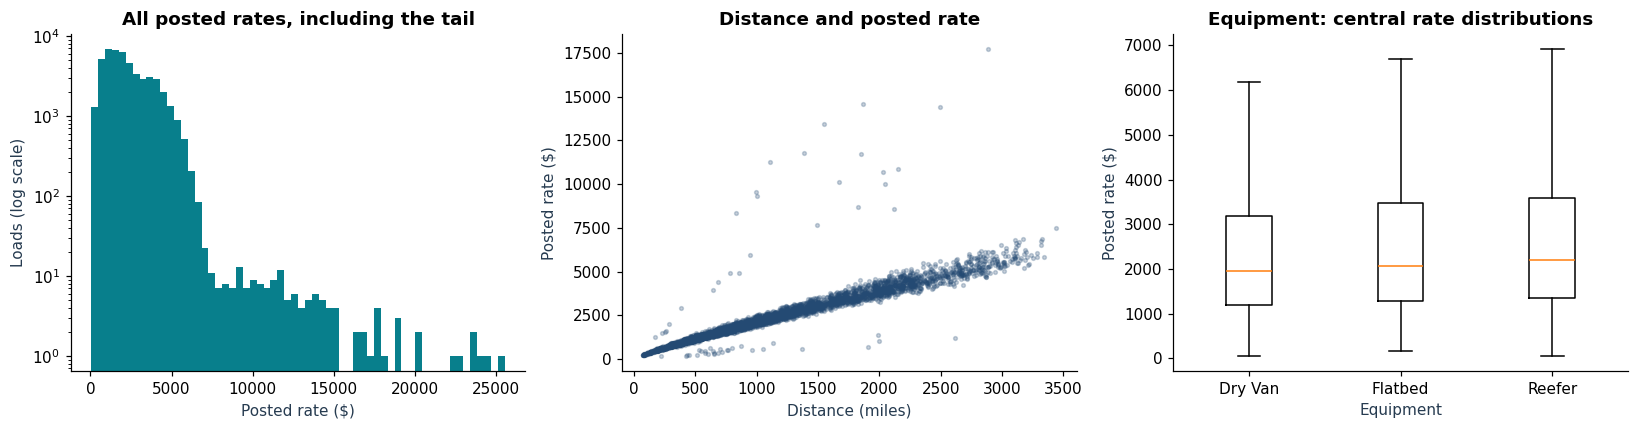

In [5]:
display(train_raw[["distance", "weight", "market_index", "quote_signal", TARGET]].describe(
    percentiles=[.01, .1, .5, .9, .95, .99]).T)
equipment_summary = train_raw.assign(rate_per_mile=train_raw[TARGET] / train_raw.distance).groupby("equipment").agg(
    loads=(TARGET, "size"), median_rate=(TARGET, "median"), mean_rate=(TARGET, "mean"),
    median_distance=("distance", "median"), median_rate_per_mile=("rate_per_mile", "median"),
)
display(equipment_summary)
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(train_raw[TARGET], bins=60, color=TEAL)
axes[0].set(yscale="log", title="All posted rates, including the tail", xlabel="Posted rate ($)", ylabel="Loads (log scale)")
sample = train_raw.sample(4000, random_state=42)
axes[1].scatter(sample.distance, sample[TARGET], s=6, alpha=.25, color=BLUE)
axes[1].set(title="Distance and posted rate", xlabel="Distance (miles)", ylabel="Posted rate ($)")
groups = [train_raw.loc[train_raw.equipment == equipment, TARGET] for equipment in equipment_summary.index]
axes[2].boxplot(groups, tick_labels=equipment_summary.index, showfliers=False)
axes[2].set(title="Equipment: central rate distributions", xlabel="Equipment", ylabel="Posted rate ($)")
figure.tight_layout()
plt.show()
print(f"Distance–rate correlation: {audit['target_distance_correlation']:.3f}")
print("Boxplot omits individual outlier markers for readability; all loads remain in training and scoring.")

### 1.5 Monthly quote relationships

Quote–rate correlation repeatedly changes sign and is close to zero in August. Quote–distance correlation also weakens in November–December. The selected models exclude `quote_signal`.

The quote-inclusive candidate also uses different calendar features, so its later comparison measures the whole candidate pipeline rather than the isolated effect of quote.

,Loads,Median rate ($),Median distance (mi),Distance–rate correlation,Quote–rate correlation,Quote–distance correlation,Market–rate correlation
month,,,,,,,
2025-01,"4,918.000","1,915.200",950.850,0.893,-0.600,-0.721,0.013
2025-02,"4,337.000","1,994.250",966.300,0.945,-0.639,-0.715,0.007
2025-03,"5,036.000","2,022.920",954.600,0.923,-0.595,-0.697,0.012
2025-04,"4,819.000","2,044.240",956.600,0.925,0.613,0.713,0.032
2025-05,"4,913.000","2,065.510",953.000,0.919,0.624,0.725,0.001
2025-06,"4,783.000","2,120.220",950.700,0.895,-0.580,-0.700,0.008
2025-07,"4,912.000","2,059.145",955.700,0.901,0.603,0.716,0.037
2025-08,"4,759.000","2,015.730",957.100,0.904,0.015,0.015,0.003
2025-09,"4,670.000","2,057.130",954.400,0.908,-0.591,-0.701,0.011


,Loads,Quote–distance correlation
month,,
2025-11,"5,836.000",0.017
2025-12,"6,164.000",0.005


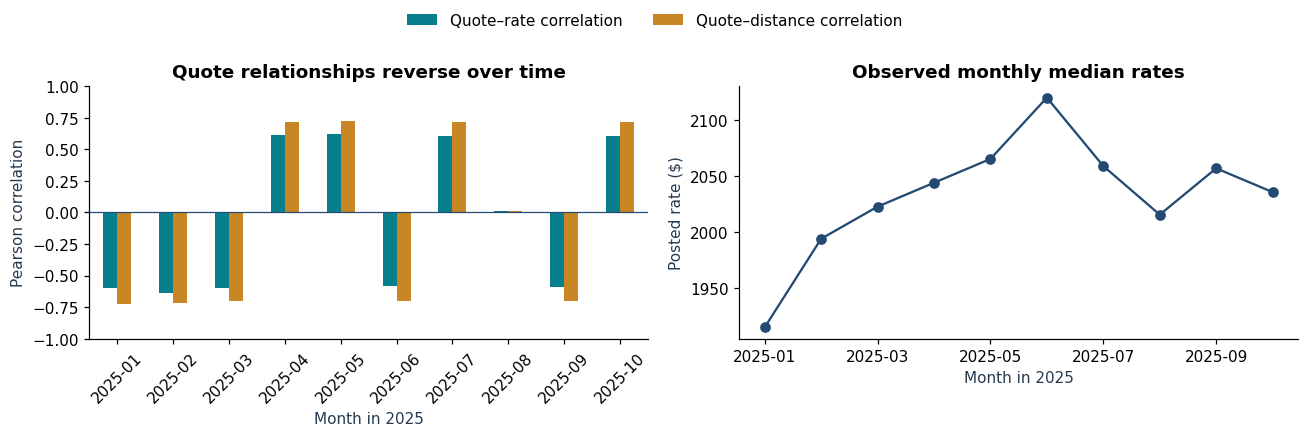

In [6]:
monthly = train_raw.assign(month=pd.to_datetime(train_raw.date).dt.strftime("%Y-%m")).groupby("month").apply(
    lambda group: pd.Series({
        "Loads": len(group), "Median rate ($)": group[TARGET].median(),
        "Median distance (mi)": group.distance.median(),
        "Distance–rate correlation": group.distance.corr(group[TARGET]),
        "Quote–rate correlation": group.quote_signal.corr(group[TARGET]),
        "Quote–distance correlation": group.quote_signal.corr(group.distance),
        "Market–rate correlation": group.market_index.corr(group[TARGET]),
    }), include_groups=False,
)
display(monthly)
future_quote = validation_raw.assign(month=pd.to_datetime(validation_raw.date).dt.strftime("%Y-%m")).groupby("month").apply(
    lambda group: pd.Series({"Loads": len(group), "Quote–distance correlation": group.quote_signal.corr(group.distance)}),
    include_groups=False,
)
display(future_quote)
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
monthly[["Quote–rate correlation", "Quote–distance correlation"]].plot.bar(ax=axes[0], color=[TEAL, GOLD], rot=45, legend=False)
axes[0].axhline(0, color=BLUE, linewidth=.8)
axes[0].set(title="Quote relationships reverse over time", xlabel="Month in 2025", ylabel="Pearson correlation", ylim=(-1, 1))
monthly["Median rate ($)"].plot(ax=axes[1], marker="o", color=BLUE)
axes[1].set(title="Observed monthly median rates", xlabel="Month in 2025", ylabel="Posted rate ($)")
figure.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False)
figure.tight_layout(rect=(0, 0, 1, .90))
plt.show()

### 1.6 Validation input coverage

Distance and equipment proportions are similar across the load files. Missing weight increases from 0.625% to 1.375%, and missing market index from 0.779% to 2.075%. These checks use predictors only; final target labels are unavailable.

In [7]:
coverage = []
for label, frame in [("Development", train_raw), ("Final validation", validation_raw), ("December scenario", december_raw)]:
    coverage.append({"Dataset": label, "Distance min": frame.distance.min(), "Distance median": frame.distance.median(),
                     "Distance max": frame.distance.max(), "Weight median |lb|": frame.weight.abs().median(),
                     "Missing weight (%)": frame.weight.isna().mean() * 100,
                     "Missing market (%)": frame.market_index.isna().mean() * 100 if "market_index" in frame else "Not supplied"})
display(pd.DataFrame(coverage))
display(pd.DataFrame({"Development (%)": train_raw.equipment.value_counts(normalize=True) * 100,
                      "Final validation (%)": validation_raw.equipment.value_counts(normalize=True) * 100}))

,Dataset,Distance min,Distance median,Distance max,Weight median |lb|,Missing weight (%),Missing market (%)
0,Development,70.000,953.300,"3,439.800","31,496.000",0.625,0.779
1,Final validation,70.000,953.600,"3,325.700","31,332.000",1.375,2.075
2,December scenario,360.000,360.000,360.000,"32,000.000",0.000,Not supplied


,Development (%),Final validation (%)
equipment,,
Dry Van,56.671,56.500
Reefer,25.094,25.425
Flatbed,18.235,18.075


## 2. Preprocessing
### 2.1 Cleaning checks

`add_candidate_features` parses dates, corrects weight signs, and derives route, calendar, and distance features without learning from other rows. The checks below verify row and target preservation, idempotence, and independence from the target and ID. Learned imputation and scaling are fitted inside each training partition.

In [8]:
prepared_train = add_candidate_features(train_raw)
prepared_validation = add_candidate_features(validation_raw)
development = prepared_train.sort_values("date", kind="stable").reset_index(drop=True)
assert len(prepared_train) == len(train_raw)
pd.testing.assert_series_equal(prepared_train[TARGET], train_raw[TARGET])
for raw, prepared in [(train_raw, prepared_train), (validation_raw, prepared_validation)]:
    assert (prepared.weight.dropna() >= 0).all()
    assert prepared.weight.isna().sum() == raw.weight.isna().sum() + (raw.weight == 0).sum()
    assert prepared.loc[raw.weight < 0, "weight"].equals(raw.loc[raw.weight < 0, "weight"].abs())
    assert prepared.loc[raw.weight.isna() | (raw.weight <= 0), "weight_invalid"].eq(1).all()
pd.testing.assert_frame_equal(add_candidate_features(prepared_train), prepared_train)
without_keys = add_candidate_features(train_raw.drop(columns=["load_id", TARGET]))
pd.testing.assert_frame_equal(without_keys[CYCLIC_FEATURES], prepared_train[CYCLIC_FEATURES])
display(prepared_train[["pickup", "delivery", "distance", "weight", "weight_invalid", "route", "year_sin", "year_cos"]].head())
print("Cleaning invariants: verified. No labeled rows or target extremes removed.")

Cleaning invariants: verified. No labeled rows or target extremes removed.


,pickup,delivery,distance,weight,weight_invalid,route,year_sin,year_cos
0,Richmond,Baltimore,274.300,"30,658.000",0,Richmond__TO__Baltimore,0.000,1.000
1,Richmond,Philadelphia,280.500,"17,555.000",0,Richmond__TO__Philadelphia,0.000,1.000
2,Philadelphia,Green Bay,967.800,"31,721.000",0,Philadelphia__TO__Green Bay,0.000,1.000
3,Hartford,Atlanta,965.400,"32,333.000",0,Hartford__TO__Atlanta,0.000,1.000
4,Dallas,Nashville,541.900,"35,183.000",0,Dallas__TO__Nashville,0.000,1.000


### 2.2 Rich and core features

The rich tree uses supplied coordinates and market index. The core tree uses only the December fields and their derivatives. Both selected trees replace raw month and day of year with annual sine/cosine terms; weekday and day of month remain available.

Huber regression uses pickup, delivery, equipment, inverse distance, weight, annual sine/cosine, and weekday, plus market index in the rich path. Multiplying its encoded design by distance/1,000 allows per-mile category effects and a fixed-cost term through inverse distance.

In [9]:
feature_contract = pd.DataFrame({
    "Feature": CYCLIC_FEATURES,
    "Rich tree": [True] * len(CYCLIC_FEATURES),
    "Core tree": [feature in CYCLIC_CORE_FEATURES for feature in CYCLIC_FEATURES],
    "Type": ["Categorical" if feature in CATEGORICAL_FEATURES else "Numeric" for feature in CYCLIC_FEATURES],
})
display(feature_contract)
scenario_features = add_candidate_features(december_raw)
assert set(CYCLIC_CORE_FEATURES).issubset(scenario_features.columns)
assert not {"load_id", TARGET, "quote_signal", "month", "day_of_year"} & set(CYCLIC_FEATURES)
assert not {"pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon", "market_index"} & set(CYCLIC_CORE_FEATURES)
display(pd.DataFrame({"Rich robust numeric": pd.Series(RobustRateModel().numeric),
                      "Core robust numeric": pd.Series(RobustRateModel(core=True).numeric)}).fillna("—"))
print("Core inference requires no absent optional fields: verified.")

Core inference requires no absent optional fields: verified.


,Feature,Rich tree,Core tree,Type
0,pickup,True,True,Categorical
1,delivery,True,True,Categorical
2,route,True,True,Categorical
3,equipment,True,True,Categorical
4,distance,True,True,Numeric
5,weight,True,True,Numeric
6,weight_invalid,True,True,Numeric
7,day_of_month,True,True,Numeric
8,day_of_week,True,True,Numeric
9,pickup_lat,True,False,Numeric


,Rich robust numeric,Core robust numeric
0,inverse_distance,inverse_distance
1,weight,weight
2,market_index,year_sin
3,year_sin,year_cos
4,year_cos,day_of_week
5,day_of_week,—


### 2.3 Training-only preprocessing

Median imputation, scaling, category vocabularies, and fallback frequencies are fitted on training rows. Unknown city labels receive the frequency-weighted contribution of training cities. The inspection below verifies the first partition's learned medians and checks that an unknown city produces a finite prediction.

In [10]:
first_partition = development.loc[development.date < "2025-05-01"]
inspection_model = RobustRateModel().fit(first_partition)
numeric_pipeline = inspection_model.preprocessor.named_transformers_["numeric"]
learned_medians = numeric_pipeline.named_steps["simpleimputer"].statistics_
expected_medians = first_partition[inspection_model.numeric].median().to_numpy()
np.testing.assert_allclose(learned_medians, expected_medians)
display(pd.DataFrame({"Numeric feature": inspection_model.numeric, "Training median": learned_medians}))
encoder = inspection_model.preprocessor.named_transformers_["categorical"]
display(pd.DataFrame({"Category": ROBUST_CATEGORIES,
                      "Training vocabulary size": [len(values) for values in encoder.categories_],
                      "Fallback weight sum": [weights.sum() for weights in inspection_model.population_weights]}))
probe = first_partition.iloc[[0]].copy()
probe["pickup"] = "__UNSEEN_CITY_CHECK__"
assert np.isfinite(inspection_model.predict(probe)).all()
print("Unknown-city fallback and training-partition imputation: verified.")
del inspection_model

Unknown-city fallback and training-partition imputation: verified.


,Numeric feature,Training median
0,inverse_distance,1.045
1,weight,"31,446.000"
2,market_index,1.039
3,year_sin,0.858
4,year_cos,0.513
5,day_of_week,3.000


,Category,Training vocabulary size,Fallback weight sum
0,pickup,64,1.000
1,delivery,64,1.000
2,equipment,3,1.000


## 3. Model evaluation
### 3.1 Forward validation and model settings

Each outer window covers two future months, matching the final forecast horizon. Early stopping uses the last month inside the training window; the selected tree count is then refitted on the full window. Outer outcomes inform model selection, not early stopping.

The core tree learns rate per mile with distance weights during fitting and early stopping. Since `distance × |predicted RPM − actual RPM| = |predicted dollars − actual dollars|`, its weighted MAE is proportional to dollar MAE. Predictions are converted to dollars before blending.

| Component | Settings |
|---|---|
| Rich CatBoost | Dollar target; MAE; depth 6; learning rate 0.05 |
| Core CatBoost | Rate-per-mile target; distance weights; MAE; depth 4; learning rate 0.05 |
| Both trees | Seed 42; maximum 600 trees; 60-round early-stopping patience; four CPU threads |
| Huber regression | Epsilon 1.35; L2 alpha 0.01; no intercept; maximum 2,000 iterations; tolerance 1e-6 |
| Ensemble | Fixed 50% tree + 50% Huber, in dollars |

In [11]:
split_plan = []
for label, start, end in FOLDS:
    train = development.loc[development.date < start]
    test = development.loc[(development.date >= start) & (development.date < end)]
    inner_cutoff = train.date.max().to_period("M").to_timestamp()
    assert train.date.max() < test.date.min()
    split_plan.append({"Fold": label, "Train start": str(train.date.min().date()),
                       "Train end": str(train.date.max().date()), "Train rows": len(train),
                       "Early-stop month": inner_cutoff.strftime("%Y-%m"),
                       "Inner train rows": int((train.date < inner_cutoff).sum()),
                       "Early-stop rows": int((train.date >= inner_cutoff).sum()),
                       "Outer start": str(test.date.min().date()), "Outer end": str(test.date.max().date()),
                       "Outer rows": len(test)})
display(pd.DataFrame(split_plan))

,Fold,Train start,Train end,Train rows,Early-stop month,Inner train rows,Early-stop rows,Outer start,Outer end,Outer rows
0,May-June,2025-01-01,2025-04-30,19110,2025-04,14291,4819,2025-05-01,2025-06-30,9696
1,July-August,2025-01-01,2025-06-30,28806,2025-06,24023,4783,2025-07-01,2025-08-31,9671
2,September-October,2025-01-01,2025-08-31,38477,2025-08,33718,4759,2025-09-01,2025-10-31,9523


### 3.2 Model comparison

All candidates use the same outer dates. Pooled metrics include every validation row, predicted once from earlier training data. These folds informed model selection and are not an untouched test set.

In [12]:
validation_results, out_of_fold = evaluate_rolling(development)
assert len(out_of_fold) == 28890 and out_of_fold.load_id.is_unique
comparison = pd.DataFrame(validation_results["pooled_metrics"])
display(comparison[["model", "rows", "mae", "rmse", "median_absolute_error", "p90_absolute_error", "mean_error"]].sort_values("mae"))
fold_results = pd.DataFrame(validation_results["fold_metrics"])
fold_mae = fold_results.pivot(index="model", columns="fold", values="mae").reindex(
    columns=[label for label, _, _ in FOLDS])
display(fold_mae)
display(pd.DataFrame(validation_results["folds"])[["fold", "tree_iterations"]])

May-June: rich MAE $134.55; core MAE $138.71
July-August: rich MAE $104.36; core MAE $134.69
September-October: rich MAE $139.46; core MAE $138.31


,model,rows,mae,rmse,median_absolute_error,p90_absolute_error,mean_error
3,Selected rich ensemble,28890,126.066,634.595,50.355,176.930,-68.135
1,Robust rich regression,28890,127.766,634.351,53.790,176.446,-63.874
2,Seasonal rich CatBoost,28890,130.260,636.425,51.350,189.334,-72.397
4,CatBoost with quote signal,28890,133.539,636.950,53.210,198.565,-55.659
7,Selected core ensemble,28890,137.233,636.111,59.908,202.495,-56.413
5,Robust core regression,28890,139.988,636.840,61.675,208.173,-53.921
6,Seasonal core CatBoost RPM,28890,146.434,639.236,64.992,227.215,-58.906
0,Training median,28890,"1,151.030","1,573.026",927.825,"2,414.215",-396.378


fold,May-June,July-August,September-October
model,,,
CatBoost with quote signal,158.343,126.692,115.237
Robust core regression,114.234,134.420,171.865
Robust rich regression,123.806,107.627,152.249
Seasonal core CatBoost RPM,179.629,138.691,120.499
Seasonal rich CatBoost,153.430,107.609,129.672
Selected core ensemble,138.713,134.693,138.305
Selected rich ensemble,134.555,104.362,139.464
Training median,"1,175.959","1,128.111","1,148.924"


,fold,tree_iterations
0,May-June,"{'rich': 192, 'core': 258, 'quote': 107}"
1,July-August,"{'rich': 600, 'core': 590, 'quote': 160}"
2,September-October,"{'rich': 597, 'core': 148, 'quote': 384}"


### 3.3 Results

The rich ensemble has the lowest pooled MAE ($126.07). Robust rich regression has slightly lower RMSE. The quote candidate wins September–October MAE; the selected ensemble wins the other two periods. The choice favors pooled dollar MAE while retaining the per-period tradeoffs.

Pooled MAE reduction relative to the evaluated quote candidate: 5.60%


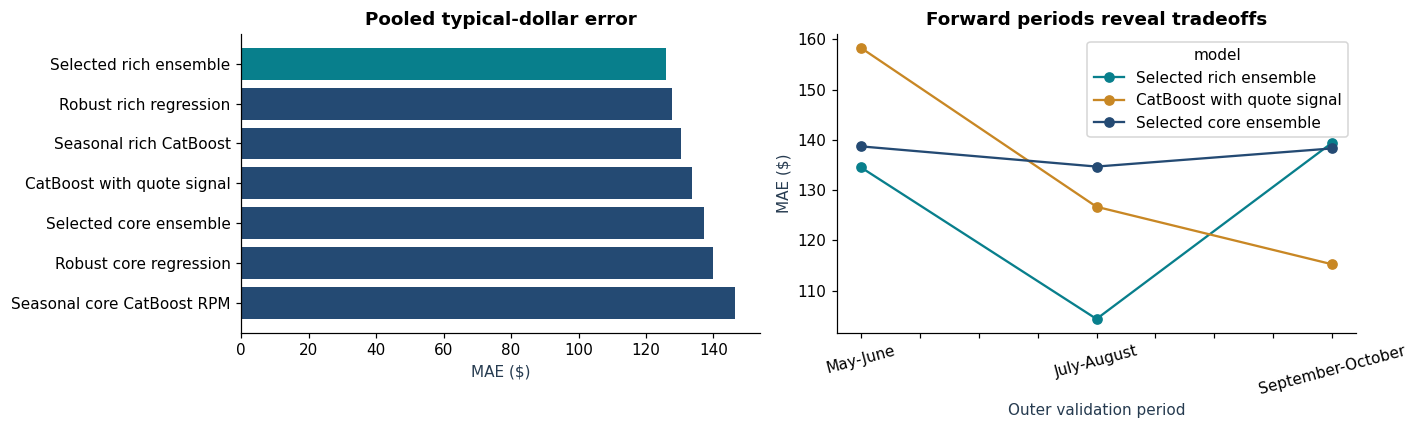

In [13]:
selected = "Selected rich ensemble"
metrics_by_model = comparison.set_index("model")
improvement = 100 * (1 - metrics_by_model.loc[selected, "mae"] / metrics_by_model.loc["CatBoost with quote signal", "mae"])
print(f"Pooled MAE reduction relative to the evaluated quote candidate: {improvement:.2f}%")
figure, axes = plt.subplots(1, 2, figsize=(13, 4))
model_subset = comparison.loc[comparison.model != "Training median"].sort_values("mae", ascending=False)
axes[0].barh(model_subset.model, model_subset.mae, color=[TEAL if name == selected else BLUE for name in model_subset.model])
axes[0].set(title="Pooled typical-dollar error", xlabel="MAE ($)")
fold_mae.loc[[selected, "CatBoost with quote signal", "Selected core ensemble"]].T.plot(ax=axes[1], marker="o", color=[TEAL, GOLD, BLUE])
axes[1].set(title="Forward periods reveal tradeoffs", xlabel="Outer validation period", ylabel="MAE ($)")
axes[1].tick_params(axis="x", rotation=15)
figure.tight_layout()
plt.show()

### 3.4 Error analysis

Mean signed error is −$68.14, indicating average underprediction. The largest 1% of absolute errors contributes 96.6% of squared error; all rows remain in the metrics.

MAE rises from $35.20 on trips up to 250 miles to $229.50 above 2,000 miles. Longer trips also have higher dollar rates, so this alone does not establish worse proportional accuracy.

,equipment,rows,mae,rmse,median_absolute_error,p90_absolute_error,mean_error
0,Dry Van,16381,117.034,647.412,43.890,151.819,-65.200
1,Flatbed,5257,137.026,574.553,62.358,219.384,-69.858
2,Reefer,7252,138.523,646.700,60.150,198.930,-73.516


,month,rows,mae,rmse,median_absolute_error,p90_absolute_error,mean_error
0,2025-05,4913,94.527,555.640,35.530,118.152,-55.871
1,2025-06,4783,175.671,719.857,89.719,254.644,-154.117
2,2025-07,4912,110.318,624.981,39.449,141.201,14.373
3,2025-08,4759,98.215,613.433,33.357,121.356,9.961
4,2025-09,4670,129.716,623.828,56.647,186.235,-104.951
5,2025-10,4853,148.845,659.713,73.026,196.059,-120.479


,Distance band (mi),rows,mae,rmse,median_absolute_error,p90_absolute_error,mean_error
0,0–250,1662,35.198,105.758,23.743,54.659,15.353
1,250–500,4584,47.520,219.758,22.809,60.430,-23.200
2,"500–1,000",9058,89.023,392.125,43.849,113.076,-52.777
3,"1,000–2,000",9033,167.653,807.066,76.722,185.483,-98.995
4,"Over 2,000",4553,229.504,951.013,125.585,290.770,-113.182


,Tail diagnostic
p99_absolute_error,"1,353.186"
top_one_percent_squared_error_share,0.966


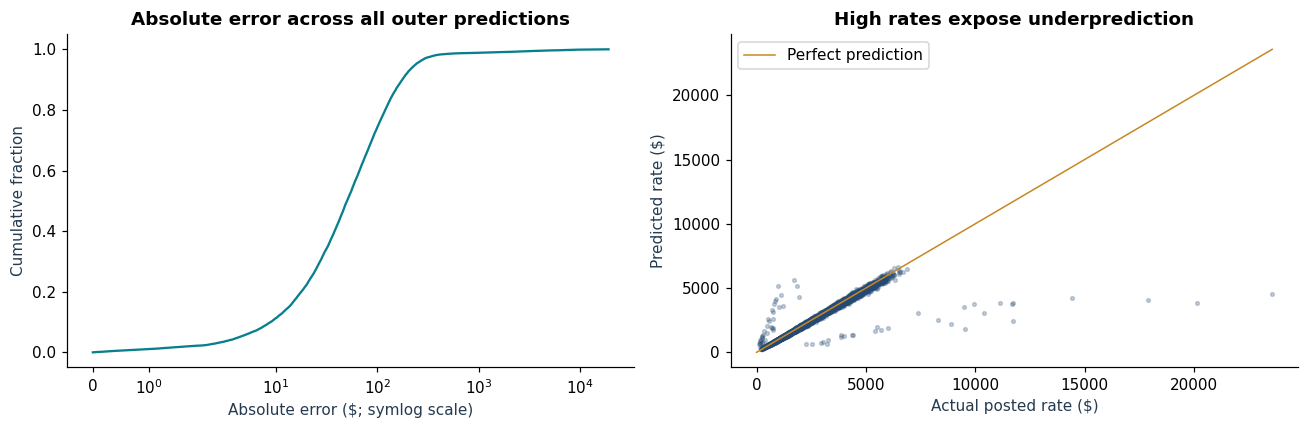

In [14]:
display(pd.DataFrame(validation_results["segments"]["equipment"]))
display(pd.DataFrame(validation_results["segments"]["month"]))
diagnostic = out_of_fold.assign(error=out_of_fold[selected] - out_of_fold[TARGET])
diagnostic["absolute_error"] = diagnostic.error.abs()
diagnostic["distance_band"] = pd.cut(diagnostic.distance, [0, 250, 500, 1000, 2000, np.inf],
                                      labels=["0–250", "250–500", "500–1,000", "1,000–2,000", "Over 2,000"])
distance_metrics = []
for band, group in diagnostic.groupby("distance_band", observed=True):
    distance_metrics.append({"Distance band (mi)": str(band), **regression_metrics(group[TARGET], group[selected])})
display(pd.DataFrame(distance_metrics))
display(pd.Series(validation_results["segments"]["error_tail"], name="Tail diagnostic").to_frame())
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
error_sorted = np.sort(diagnostic.absolute_error.to_numpy())
axes[0].plot(error_sorted, np.arange(1, len(error_sorted) + 1) / len(error_sorted), color=TEAL)
axes[0].set(xscale="symlog", title="Absolute error across all outer predictions", xlabel="Absolute error ($; symlog scale)", ylabel="Cumulative fraction")
plot_sample = diagnostic.sample(4000, random_state=42)
axes[1].scatter(plot_sample[TARGET], plot_sample[selected], alpha=.25, s=6, color=BLUE)
limit = max(plot_sample[TARGET].max(), plot_sample[selected].max())
axes[1].plot([0, limit], [0, limit], color=GOLD, linewidth=1, label="Perfect prediction")
axes[1].set(title="High rates expose underprediction", xlabel="Actual posted rate ($)", ylabel="Predicted rate ($)")
axes[1].legend()
figure.tight_layout()
plt.show()

### 3.5 Unseen-city test

Eight cities are excluded from January–June training, then evaluated on July–August loads involving those cities. Preprocessing and early stopping use only the reduced training data. This is a separate diagnostic sample, not a direct comparison with the pooled score.

In [15]:
city_stress = evaluate_unseen_cities(development)
display(pd.DataFrame([{"Model": "Rich ensemble", **city_stress["rich"]},
                      {"Model": "Core ensemble", **city_stress["core"]}]))
print("Withheld cities:", ", ".join(city_stress["held_cities"]))
print("Training rows:", city_stress["training_rows"], "Stress-test rows:", city_stress["test_rows"])

Withheld cities: Atlanta, Dallas, Denver, Houston, Miami, Portland, Seattle, Tampa
Training rows: 25726 Stress-test rows: 1009


,Model,rows,mae,rmse,median_absolute_error,p90_absolute_error,mean_error
0,Rich ensemble,1009,91.981,701.521,28.358,82.960,-26.217
1,Core ensemble,1009,102.580,699.997,34.670,111.475,-11.341


### 3.6 Final fit and export

October selects the final tree counts: 476 rich and 510 core. Both ensembles are then refitted on all 48,000 labeled loads. Rich predictions follow the template's ID order; the core model supplies the December scenario.

The checks verify output schemas, positive finite rates, fixed scenario fields, and unchanged source hashes. Feature importance describes only the rich tree component.

In [16]:
# Keep notebook styling separate from the supplied scorer's default chart design.
with plt.rc_context():
    plt.rcdefaults()
    final_fit = predict_submission(development, validation_raw, december_raw, template, ROOT)
predictions = pd.read_csv(ROOT / "validation_predictions.csv")
december_predictions = pd.read_csv(ROOT / "december_predictions.csv")
validate_predictions(predictions)
validate_december(december_predictions)
assert list(predictions.columns) == ["load_id", "predicted_rate"]
assert predictions.load_id.tolist() == template.load_id.tolist()
pd.testing.assert_frame_equal(december_predictions.drop(columns="predicted_rate"), december_raw.drop(columns="predicted_rate"))
assert source_hashes == {name: hashlib.sha256((ROOT / name).read_bytes()).hexdigest() for name in source_names}
display(predictions.head())
print("Validated prediction rows:", len(predictions), "December rows:", len(december_predictions))
print("Final rich trees:", final_fit["rich_iterations"], "Final core trees:", final_fit["core_iterations"])
display(pd.Series(final_fit["tree_importance"], name="Rich tree prediction-value importance").sort_values(ascending=False).head(10).to_frame())
print("Source CSV hashes and fixed scenario inputs: unchanged.")

Validated prediction rows: 12000 December rows: 31
Final rich trees: 476 Final core trees: 510
Source CSV hashes and fixed scenario inputs: unchanged.


,load_id,predicted_rate
0,TE-000001,848.381
1,TE-000002,"4,981.564"
2,TE-000003,"5,074.515"
3,TE-000004,"3,950.806"
4,TE-000005,"1,829.197"


,Rich tree prediction-value importance
distance,36.838
inverse_distance,32.813
log_distance,22.079
equipment,3.240
pickup_lon,1.063
weight,0.876
year_cos,0.735
market_index,0.562
pickup_lat,0.522
delivery_lat,0.451


### 3.7 December forecast

Lexington to Fort Wayne; 360 miles; Dry Van; 32,000 lb; December 1–31, 2025. Only the date changes. The supplied scorer generates this chart from the core predictions. It is a point-estimate scenario, not a confidence interval.

December scenario range: $805.56 to $815.87


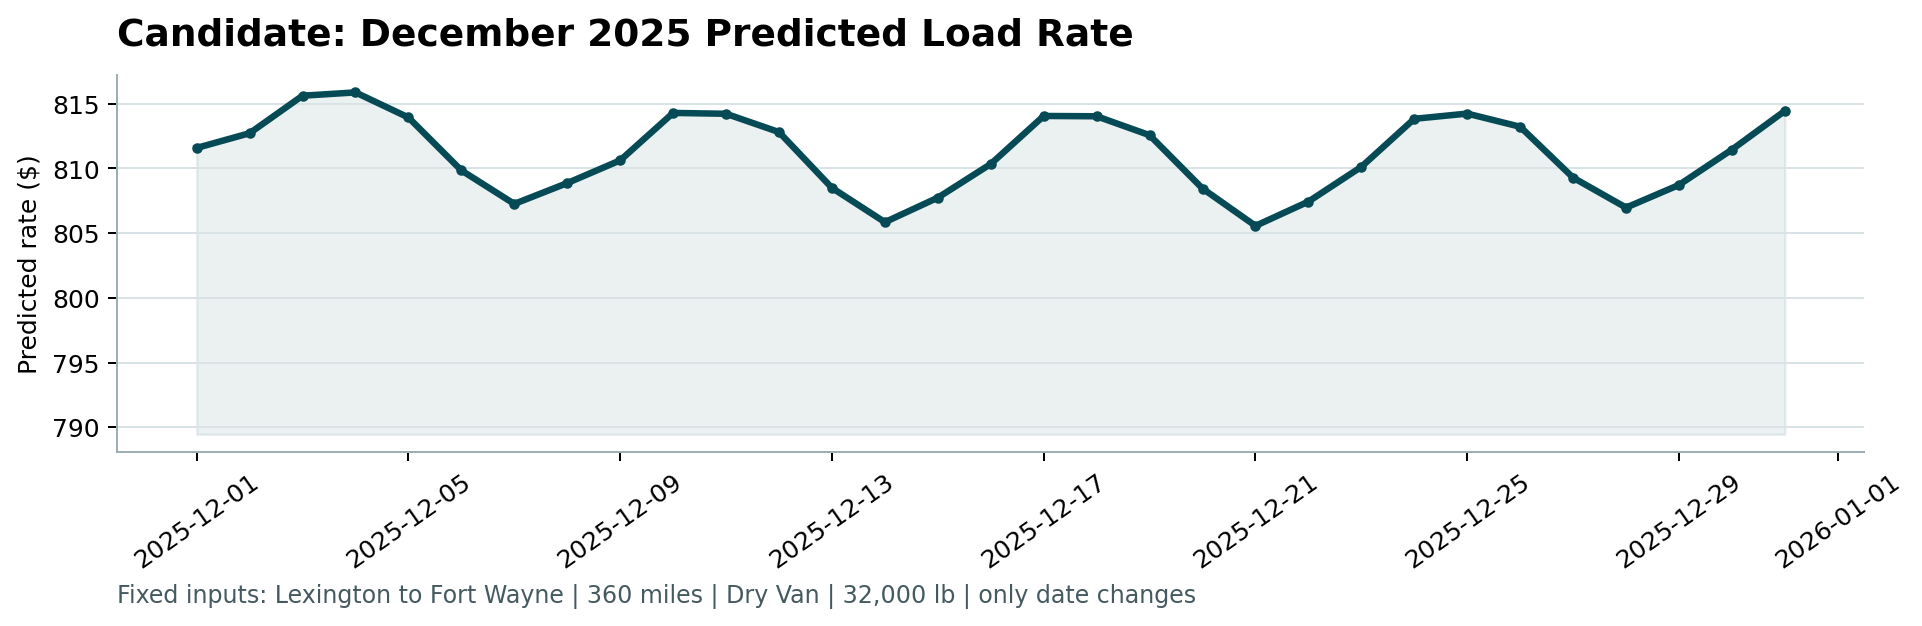

,date,predicted_rate
0,2025-12-01,811.581
1,2025-12-02,812.718
2,2025-12-03,815.615
3,2025-12-04,815.870
4,2025-12-05,813.933


In [17]:
display(Image(filename=str(ROOT / "results" / "candidate_december.png")))
display(december_predictions[["date", "predicted_rate"]].head())
print(f"December scenario range: ${december_predictions.predicted_rate.min():,.2f} to ${december_predictions.predicted_rate.max():,.2f}")

### 3.8 Output verification

Reproduced metrics, final tree counts, and source hashes are checked against `results/validation_summary.json`.

In [18]:
saved_summary = json.loads((ROOT / "results" / "validation_summary.json").read_text(encoding="utf-8"))
saved_metrics = pd.DataFrame(saved_summary["validation"]["pooled_metrics"]).set_index("model")
for metric in ["mae", "rmse", "median_absolute_error", "p90_absolute_error", "mean_error"]:
    np.testing.assert_allclose(metrics_by_model[metric], saved_metrics.loc[metrics_by_model.index, metric], rtol=1e-7, atol=1e-5)
for name in ["rich_iterations", "core_iterations", "validation_rows", "december_rows"]:
    assert final_fit[name] == saved_summary["final_fit"][name]
assert source_hashes == saved_summary["input_sha256"]
print("Notebook, shared implementation, and submitted validation summary agree.")

Notebook, shared implementation, and submitted validation summary agree.


## Limitations

- Only ten months of one year are labeled. Annual seasonality and winter behavior cannot be independently verified.
- The rolling folds informed model selection. November–December labels are unavailable for an independent final score.
- Extreme rates, missing market context, and new lanes remain sources of error. The December curve contains point estimates without calibrated uncertainty.

`README.md` contains setup and run instructions. The supplied scorer validates output structure and generates the chart; it does not calculate hidden accuracy.